In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv(r'D:\Python study material\placement.csv')

In [19]:
df.shape

(100, 4)

In [20]:
df.sample(5)

,Unnamed: 0,cgpa,iq,placement
70,70,6.3,127.0,1
27,27,6.0,124.0,1
65,65,8.1,166.0,1
56,56,6.1,65.0,0
80,80,4.9,196.0,0


C:\Users\shubham sandip kale\AppData\Local\Temp\ipykernel_9560\49520821.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])


KeyError: 'placement_exam_marks'

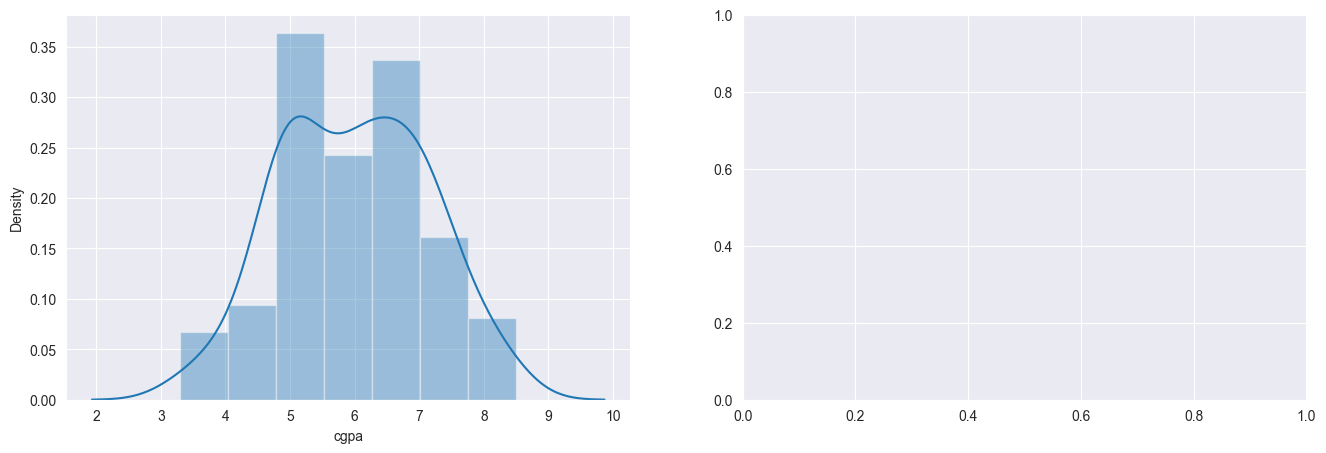

In [40]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

plt.show()

In [23]:
df['placement_exam_marks'].skew()

KeyError: 'placement_exam_marks'

In [24]:
print("Mean value of cgpa",df['cgpa'].mean())
print("Std value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Mean value of cgpa 5.9910000000000005
Std value of cgpa 1.1436336737775692
Min value of cgpa 3.3
Max value of cgpa 8.5


In [25]:
# Finding the boundary values
print("Highest allowed",df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed",df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed 9.421901021332708
Lowest allowed 2.560098978667293


In [26]:
# Finding the outliers
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]

,Unnamed: 0,cgpa,iq,placement
7,7,5.0,63.0,0
9,9,5.1,66.0,0
15,15,5.1,176.0,0
17,17,3.3,183.0,0
18,18,4.0,100.0,0
22,22,4.9,120.0,0
23,23,4.7,87.0,0
24,24,4.7,121.0,0
25,25,5.0,91.0,0
31,31,3.9,109.0,0


## Trimming

In [27]:
# Trimming

new_df = df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]
new_df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
92,92,5.2,110.0,0
93,93,6.8,112.0,1
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [28]:
# Approach 2

# Calculating the Zscore

df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()

In [29]:
df.head()

,Unnamed: 0,cgpa,iq,placement,cgpa_zscore
0,0,6.8,123.0,1,0.707394
1,1,5.9,106.0,0,-0.079571
2,2,5.3,121.0,0,-0.604214
3,3,7.4,132.0,1,1.232038
4,4,5.8,142.0,0,-0.167012


In [30]:
df[df['cgpa_zscore'] > 3]

,Unnamed: 0,cgpa,iq,placement,cgpa_zscore


In [31]:
df[df['cgpa_zscore'] < -3]

,Unnamed: 0,cgpa,iq,placement,cgpa_zscore


In [32]:
df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]

,Unnamed: 0,cgpa,iq,placement,cgpa_zscore


In [33]:
# Trimming 
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

In [34]:
new_df

,Unnamed: 0,cgpa,iq,placement,cgpa_zscore
0,0,6.8,123.0,1,0.707394
1,1,5.9,106.0,0,-0.079571
2,2,5.3,121.0,0,-0.604214
3,3,7.4,132.0,1,1.232038
4,4,5.8,142.0,0,-0.167012
...,...,...,...,...,...
95,95,4.3,200.0,0,-1.478620
96,96,4.4,42.0,0,-1.391180
97,97,6.7,182.0,1,0.619954
98,98,6.3,103.0,1,0.270191


## Capping

In [35]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [36]:
lower_limit

np.float64(2.560098978667293)

In [37]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [38]:
df.shape

(100, 5)

In [39]:
df['cgpa'].describe()

count    100.000000
mean       5.991000
std        1.143634
min        3.300000
25%        5.075000
50%        6.000000
75%        6.900000
max        8.500000
Name: cgpa, dtype: float64